In [58]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [60]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [61]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=30)

In [63]:
X_train['Age_imp']=X_train['Age']
X_test['Age_imp']=X_test['Age']

In [64]:
X_train['Age_imp'][X_train['Age_imp'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imp'][X_test['Age_imp'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\Preethika\AppData\Local\Temp\ipykernel_37480\316057343.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imp'][X_train['Age_imp'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
C:\Use

In [65]:
#Extract the random samples needed to fill the missing values
train_samples = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(), random_state=0)
test_samples = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum(), random_state=0)

#Align the index of the random samples with the missing rows' index
train_samples.index = X_train[X_train['Age'].isnull()].index
test_samples.index = X_test[X_test['Age'].isnull()].index

#Use .loc to assign the sampled values to the missing slots
X_train.loc[X_train['Age'].isnull(), 'Age_imp'] = train_samples
X_test.loc[X_test['Age'].isnull(), 'Age_imp'] = test_samples


In [66]:
X_train['Age'].isnull().sum()

np.int64(125)

In [67]:
X_train

,Age,Fare,Age_imp
862,48.0,25.9292,48.0
704,26.0,7.8542,26.0
525,40.5,7.7500,40.5
234,24.0,10.5000,24.0
518,36.0,26.0000,36.0
...,...,...,...
140,NaN,15.2458,19.0
500,17.0,8.6625,17.0
813,6.0,31.2750,6.0
421,21.0,7.7333,21.0


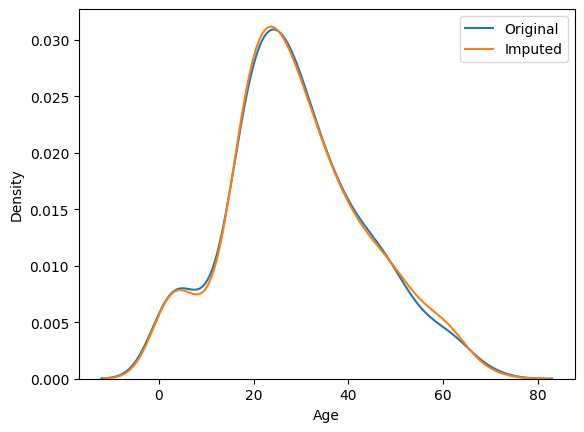

In [68]:
sns.kdeplot(X_train['Age'],label='Original')
sns.kdeplot(X_train['Age_imp'],label = 'Imputed')

plt.legend()
plt.show()

In [69]:
X_train[['Fare', 'Age', 'Age_imp']].cov()

,Fare,Age,Age_imp
Fare,2456.830957,75.961861,51.235699
Age,75.961861,210.190882,210.190882
Age_imp,51.235699,210.190882,212.166737


<Axes: >

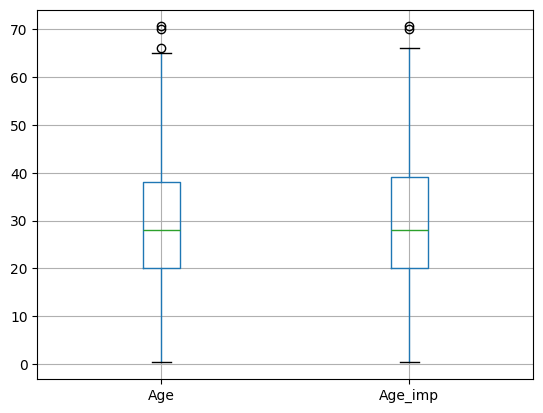

In [70]:
X_train[['Age', 'Age_imp']].boxplot()

In [71]:
# In fututure if the age is 40 and fare is 50 it should remine same in the future ,it should not select new ramdom number
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

NameError: name 'observation' is not defined

In [ ]:
#catagorical data

data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [ ]:
X = data
y = data['SalePrice']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
#imputed values added
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [ ]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\Preethika\AppData\Local\Temp\ipykernel_37480\856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['Garage

In [ ]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [ ]:
temp

,original,imputed
TA,0.951043,0.952911
Fa,0.037171,0.035959
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


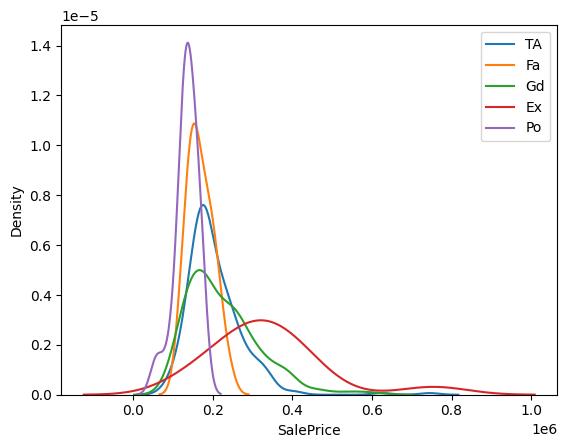

In [ ]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        data=X_train[X_train['FireplaceQu'] == category], 
        x='SalePrice', 
        label=category
    )
plt.legend()
plt.show()

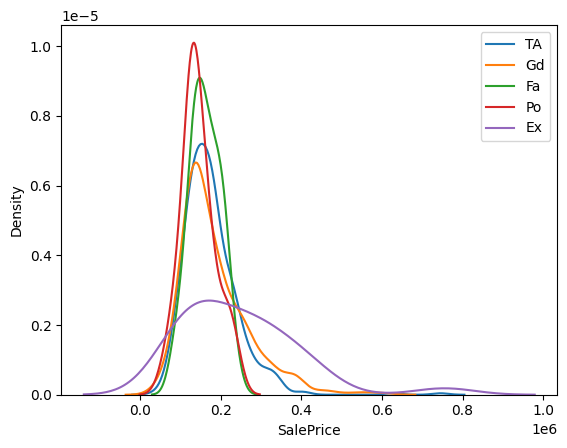

In [ ]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.legend()
plt.show()